In [1]:
import sys, time
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from DGP import generate_market
from da import deferred_acceptance
from sd import serial_dictatorship
from mip import solve_mip

sns.set_theme(style="whitegrid")
%matplotlib inline

### Simulate test data (default)

In [2]:
SEED = 42
SOLVER = "GUROBI"

m_default = generate_market(n_students=20, n_courses=8, seed=SEED)
print(f"Students : {m_default.n_students}  ({m_default.phd_students.sum()} PhD)")
print(f"Courses  : {m_default.n_courses}  ({m_default.phd_required.sum()} require PhD TA)")
print(f"Total slots: {m_default.capacities.sum()}  (vs {m_default.n_students} students)")

Students : 20  (7 PhD)
Courses  : 8  (5 require PhD TA)
Total slots: 16  (vs 20 students)


In [3]:
# run all algorithms on default simulated data 
def _time(fn, *args, **kwargs):
    t0 = time.perf_counter()
    result = fn(*args, **kwargs)
    return result, time.perf_counter() - t0

a_da, t_da = _time(deferred_acceptance, m_default)
a_sd, t_sd = _time(serial_dictatorship, m_default, seed=SEED)

res_student     = solve_mip(m_default, objective="student",     solver=SOLVER)
res_course      = solve_mip(m_default, objective="course",      solver=SOLVER)
res_bilateral   = solve_mip(m_default, objective="bilateral",   solver=SOLVER)
res_egalitarian = solve_mip(m_default, objective="egalitarian", solver=SOLVER)
res_lp          = solve_mip(m_default, objective="student", lp_relax=True, solver=SOLVER)

results = {
    "DA":              (a_da,                      t_da),
    "SD":              (a_sd,                      t_sd),
    "MIP-student":     (res_student.assignment,    res_student.solve_time),
    "MIP-course":      (res_course.assignment,     res_course.solve_time),
    "MIP-bilateral":   (res_bilateral.assignment,  res_bilateral.solve_time),
    "MIP-egalitarian": (res_egalitarian.assignment,res_egalitarian.solve_time),
    "LP-student":      (res_lp.assignment,         res_lp.solve_time),
}
print("All algorithms done.")


Restricted license - for non-production use only - expires 2027-11-29
All algorithms done.


### Rank
Some commentary (?)
box spans 15th to 75th percentiles (middle 50)
low rank means matching is more prefered, short boxes are more desirable 

Means at least 50% of all students under all algorithms always get top choice

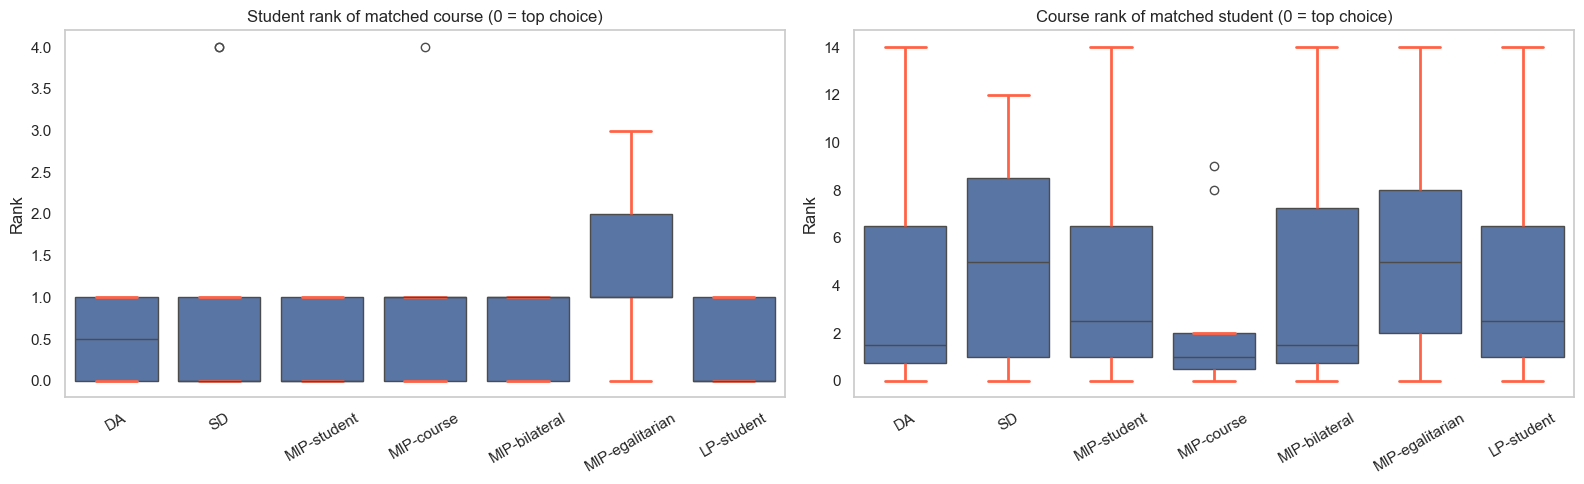

In [4]:
# box plot for each algorithm on student choice rank
# build rank df
rank_rows = []
course_rank_rows = []

for name, (a, _) in results.items():
    for i in range(m_default.n_students):
        if a[i] >= 0:
            j = a[i]
            rank_rows.append({"Algorithm": name, "Rank": int(m_default.student_rankings[i, j])})
            course_rank_rows.append({"Algorithm": name, "Rank": int(m_default.course_rankings[j, i])})

student_rank_df = pd.DataFrame(rank_rows)
course_rank_df = pd.DataFrame(course_rank_rows)

fig, axes = plt.subplots(1, 2, figsize=(16, 5))

sns.boxplot(data=student_rank_df, x="Algorithm", y="Rank", ax=axes[0],
            whiskerprops=dict(color="tomato", linewidth=2),
            capprops=dict(color="tomato", linewidth=2))
axes[0].set_title("Student rank of matched course (0 = top choice)")
axes[0].set_xlabel("")
axes[0].tick_params(axis="x", rotation=30)

sns.boxplot(data=course_rank_df, x="Algorithm", y="Rank", ax=axes[1],
            whiskerprops=dict(color="tomato", linewidth=2),
            capprops=dict(color="tomato", linewidth=2))
axes[1].set_title("Course rank of matched student (0 = top choice)")
axes[1].set_xlabel("")
axes[1].tick_params(axis="x", rotation=30)

for ax in axes.flat:
    ax.grid(False)

plt.tight_layout()
plt.show()


### Objective value

Note on why min utility is negative for SD and DA: Because utility u_ij = θ_i · φ_j + ε_ij is a dot product of normal vectors plus noise — it has no floor, so it can naturally be negative. A negative utility just means student i and course j are a poor match (their latent skill vectors point in opposite directions).

DA and SD don't optimise utility, just follow preference rankings. So a student might get their top-ranked course even if the raw utility score for that course happens to be negative, because it's still better than all their other options.

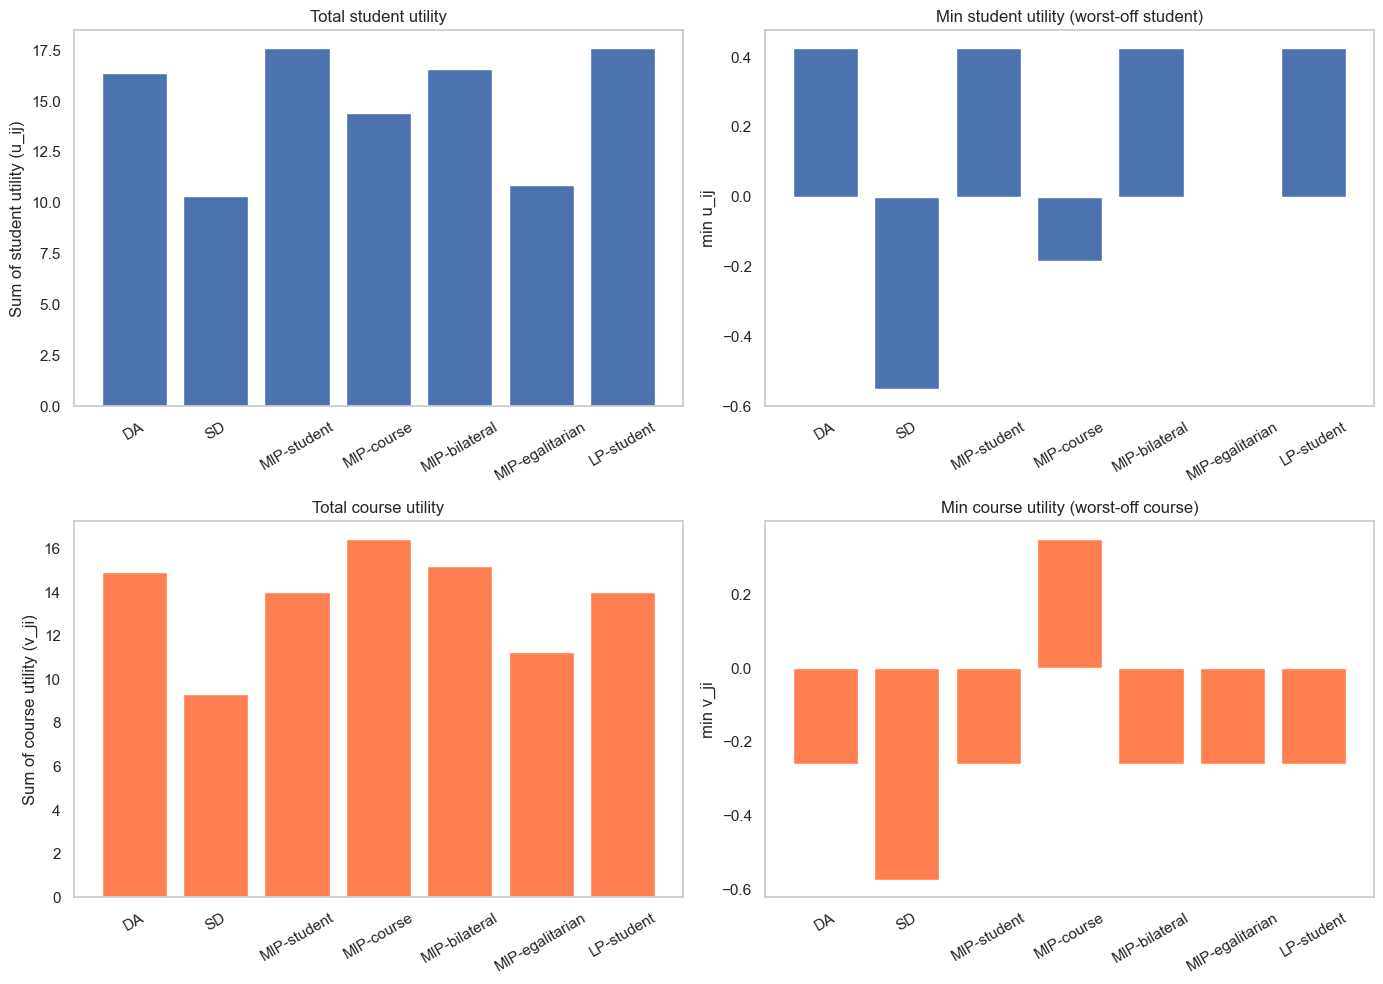

In [5]:
def student_utils(a):
    return [m_default.student_scores[i, a[i]] for i in range(m_default.n_students) if a[i] >= 0]

def course_utils(a):
    return [m_default.course_scores[a[i], i] for i in range(m_default.n_students) if a[i] >= 0]

s_metrics = {name: student_utils(a) for name, (a, _) in results.items()}
c_metrics  = {name: course_utils(a)  for name, (a, _) in results.items()}

total_s = {name: sum(u)  for name, u in s_metrics.items()}
min_s   = {name: min(u)  for name, u in s_metrics.items()}
total_c = {name: sum(u)  for name, u in c_metrics.items()}
min_c   = {name: min(u)  for name, u in c_metrics.items()}

fig, axes = plt.subplots(2, 2, figsize=(14, 10))

axes[0,0].bar(total_s.keys(), total_s.values())
axes[0,0].set_title("Total student utility")
axes[0,0].set_ylabel("Sum of student utility (u_ij)")
axes[0,0].tick_params(axis="x", rotation=30)

axes[0,1].bar(min_s.keys(), min_s.values())
axes[0,1].set_title("Min student utility (worst-off student)")
axes[0,1].set_ylabel("min u_ij")
axes[0,1].tick_params(axis="x", rotation=30)

axes[1,0].bar(total_c.keys(), total_c.values(), color="coral")
axes[1,0].set_title("Total course utility")
axes[1,0].set_ylabel("Sum of course utility (v_ji)")
axes[1,0].tick_params(axis="x", rotation=30)

axes[1,1].bar(min_c.keys(), min_c.values(), color="coral")
axes[1,1].set_title("Min course utility (worst-off course)")
axes[1,1].set_ylabel("min v_ji")
axes[1,1].tick_params(axis="x", rotation=30)

for ax in axes.flat:
    ax.grid(False)

plt.tight_layout()
plt.show()



### Fairness
some commentary idk...

Metrics used:

Gini coefficient
Measures inequality in the distribution of student utilities. For every pair of matched students, compute the absolute difference in their utilities, sum all pairs, and normalise by total utility and number of students. Ranges from 0 (everyone gets identical utility) to 1 (one student gets everything). Since utilities can be negative in our DGP, we shift by subtracting the minimum before computing so Gini index is always positive.

Envy count
For every pair of students (i, i'), counts whether student i prefers i's assigned course over their own — i.e. u_i,a[i'] > u_i,a[i]. Unmatched students are counted as envying every matched student. A count of 0 would mean the assignment is envy-free, lower counts indicate less envy overall. I make the assumption that being unmatched is worse than any possible match (to be consistent with SD and DA, so there is no real outside option). 

Rank std dev
Takes the preference list rank of each matched student's assigned course (0 = top choice) and computes the standard deviation across all matched students. A low std dev means students were treated consistently, i.e. no student got dramatically better or worse treatment relative to others. A high std dev means the algorithm is highly unequal in how well it serves different students.

In [6]:
def gini(utils):
    u = np.sort(np.abs(utils))
    n = len(u)
    return (2 * np.dot(np.arange(1, n+1), u) / (n * u.sum()) - (n+1)/n) if u.sum() > 0 else 0.0

def envy_count(assignment, market):
    count = 0
    for i in range(market.n_students):
        for ip in range(market.n_students):
            if ip == i or assignment[ip] < 0:
                continue # i envies i' if i prefers i''s course over their own current situation
            if assignment[i] < 0: # unmatched i always envies any matched i'
                count += 1
                break
            u_i_own = market.student_scores[i, assignment[i]]
            u_i_gets_ip = market.student_scores[i, assignment[ip]]
            if u_i_gets_ip > u_i_own + 1e-9:
                count += 1
                break
    return count

rows = []
for label, (a, rt) in results.items():
    matched = a[a >= 0]
    utils = np.array([m_default.student_scores[i, a[i]] for i in range(m_default.n_students) if a[i] >= 0])
    all_utils = np.where(a >= 0, m_default.student_scores[np.arange(m_default.n_students), np.clip(a, 0, None)], 0.0)
    rows.append({
        "Algorithm": label,
        "Gini": round(gini(utils), 3) if len(utils) else float("nan"),
        "Envy count": envy_count(a, m_default),
        "Rank std dev": round(float(np.std([m_default.student_rankings[i, a[i]] for i in range(m_default.n_students) 
                                            if a[i] >= 0])), 3),
    })

df_fair = pd.DataFrame(rows).set_index("Algorithm")
display(df_fair)

,Gini,Envy count,Rank std dev
Algorithm,,,
DA,0.266,14,0.500
SD,0.242,14,1.477
MIP-student,0.259,13,0.493
MIP-course,0.302,16,1.083
MIP-bilateral,0.305,15,0.493
MIP-egalitarian,0.382,15,0.799
LP-student,0.259,13,0.493


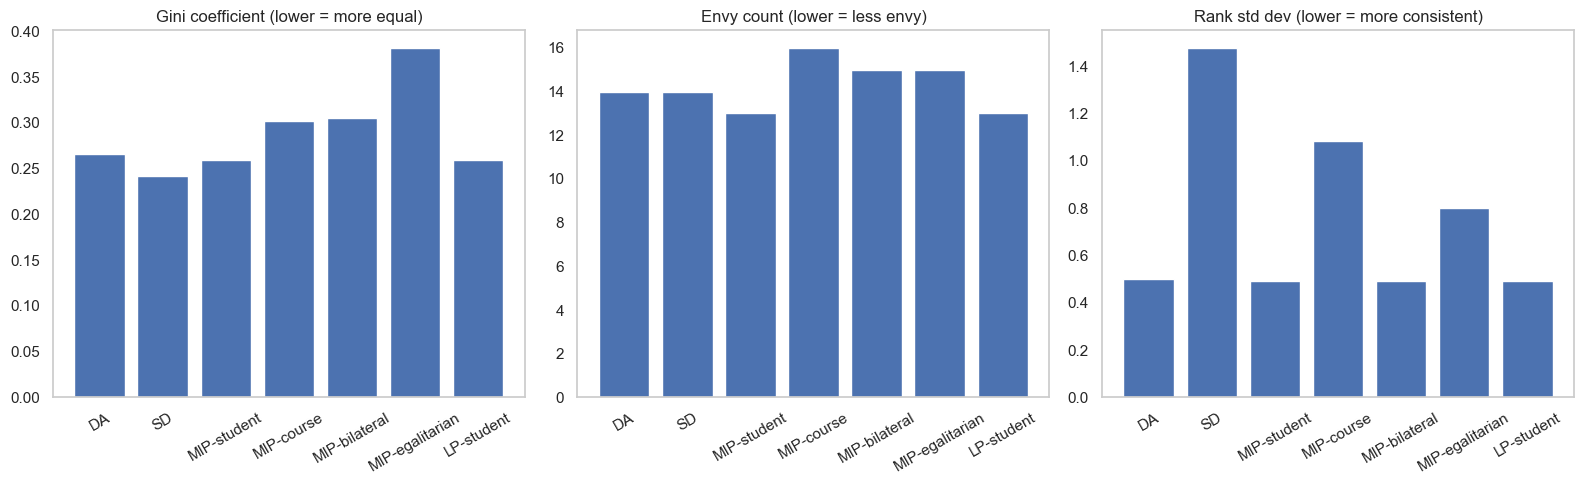

In [7]:
# plot
fairness_df = pd.DataFrame(rows).set_index("Algorithm")
fig, axes = plt.subplots(1, 3, figsize=(16, 5))
metrics_info = [
    ("Gini",         "Gini coefficient (lower = more equal)"),
    ("Envy count",   "Envy count (lower = less envy)"),
    ("Rank std dev", "Rank std dev (lower = more consistent)"),
]

for ax, (col, title) in zip(axes, metrics_info):
    ax.bar(fairness_df.index, fairness_df[col])
    ax.set_title(title)
    ax.tick_params(axis="x", rotation=30)
    ax.grid(False)

plt.tight_layout()
plt.show()

### Welfare

Blocking pairs: by definitions number of blocking pairs for DA is zero; this is one measure of the efficiency of the matching algorithm

In [8]:
# check for blocking pairs
def count_blocking_pairs(assignment, market):
    pref_set = [set(prefs) for prefs in market.student_prefs]
    blocking = 0
    for i in range(market.n_students):
        for j in range(market.n_courses):
            if j not in pref_set[i]: # course not listed
                continue
            if market.phd_required[j] and not market.phd_students[i]:
                continue
            if i in market.course_rejections[j]:
                continue
            if assignment[i] == j:
                continue
            # does i prefer j over current match (or is unmatched)?
            if assignment[i] >= 0:
                if market.student_rankings[i, j] >= market.student_rankings[i, assignment[i]]:
                    continue
            # can j accommodate i?
            assigned_to_j = np.where(assignment == j)[0]
            if len(assigned_to_j) < market.capacities[j]:
                blocking += 1  # if course j has < capacity
            elif any(market.course_rankings[j, i] < market.course_rankings[j, k]
                     for k in assigned_to_j):
                blocking += 1  # j prefers i over someone it holds
    return blocking

# print table
for label, (a, _) in results.items():
    bp = count_blocking_pairs(a, m_default)
    print(f"{label:20s}  blocking pairs: {bp}")


DA                    blocking pairs: 0
SD                    blocking pairs: 11
MIP-student           blocking pairs: 4
MIP-course            blocking pairs: 6
MIP-bilateral         blocking pairs: 3
MIP-egalitarian       blocking pairs: 14
LP-student            blocking pairs: 4


### pareto-efficiency? 
- difficult to calculate directly, but have some other ways to test or compare since MIP optimized solution is by construction pareto optimal, so I want to compare how SD and AD does compared to the centralized system

Metrics:
Aggregate welfare (total student utility under MIP - total utility under DA or SD)

Dominated students (how many students are strictly worse off under DA or SD)
Each row = one algorithm, each column = one student. Color = u_i(MIP) - u_i(algorithm): so SD has the biggest differences

Utility gap (for each student the utlity difference between MIP and DA or SD)

,Welfare loss,Worse off,Same,Better off
Algorithm,,,,
DA,1.199,0,11,0
SD,7.259,1,7,1
MIP-course,3.156,2,8,0
MIP-bilateral,0.994,2,9,0
MIP-egalitarian,6.734,5,5,0
LP-student,0.000,0,12,0


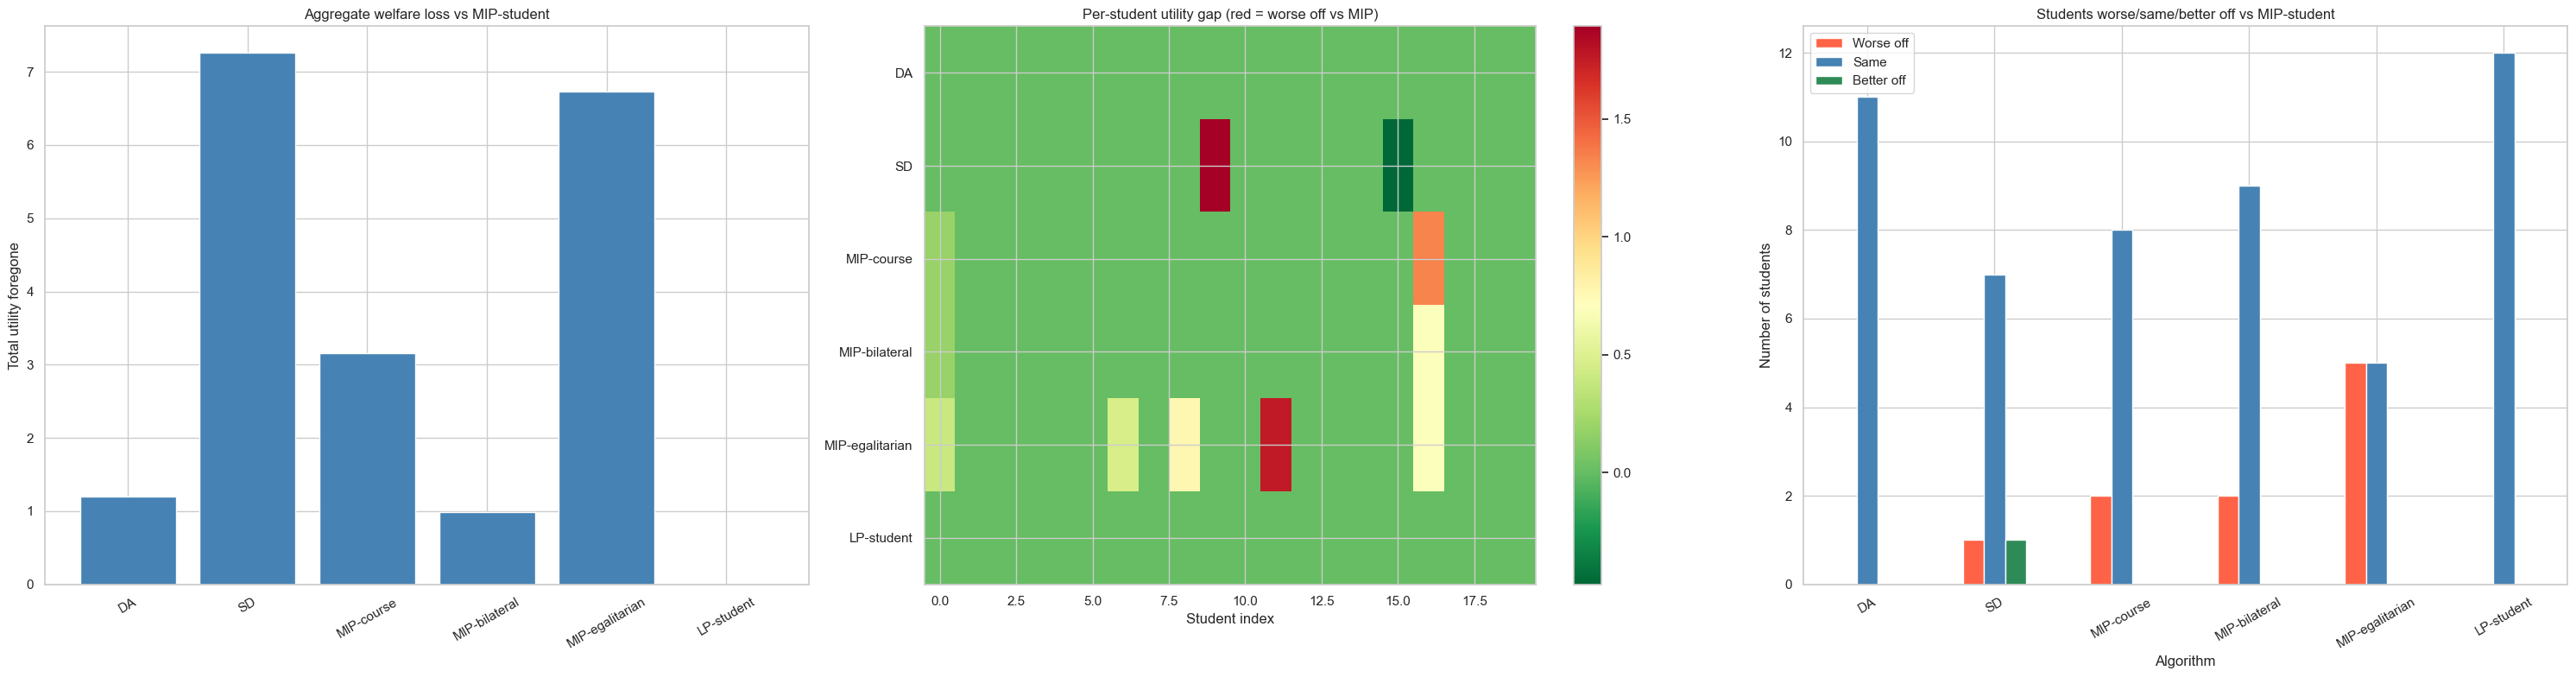

In [9]:
mip_a = results["MIP-student"][0]
comparisons = [k for k in results if k != "MIP-student"]

def student_utility(assignment, market):
    return np.array([
        market.student_scores[i, assignment[i]] if assignment[i] >= 0 else np.nan
        for i in range(market.n_students)
    ])

mip_utils = student_utility(mip_a, m_default)
mip_total = np.nansum(mip_utils)

# aggregate welfare loss
rows = []
# by algorithm
for label in comparisons:
    a = results[label][0]
    alg_utils = student_utility(a, m_default)
    gap = mip_utils - alg_utils
    rows.append({
        "Algorithm": label,
        "Welfare loss": round(mip_total - np.nansum(alg_utils), 3),
        "Worse off": int(np.sum(gap >  1e-9)),
        "Same":      int(np.sum(np.abs(gap) <= 1e-9)),
        "Better off":int(np.sum(gap < -1e-9)),
    })

df_welfare = pd.DataFrame(rows).set_index("Algorithm")
display(df_welfare)

# plot
fig, axes = plt.subplots(1, 3, figsize=(30, 8))

axes[0].bar(df_welfare.index, df_welfare["Welfare loss"], color="steelblue")
axes[0].set_title("Aggregate welfare loss vs MIP-student")
axes[0].set_ylabel("Total utility foregone")
axes[0].tick_params(axis="x", rotation=30)

gap_matrix = np.array([
    np.nan_to_num(mip_utils - student_utility(results[l][0], m_default), nan=0.0)
    for l in comparisons
])
im = axes[1].imshow(gap_matrix, aspect="auto", cmap="RdYlGn_r")
axes[1].set_yticks(range(len(comparisons)))
axes[1].set_yticklabels(comparisons)
axes[1].set_xlabel("Student index")
axes[1].set_title("Per-student utility gap (red = worse off vs MIP)")
plt.colorbar(im, ax=axes[1])

df_welfare[["Worse off", "Same", "Better off"]].plot(
    kind="bar", ax=axes[2], color=["tomato", "steelblue", "seagreen"], legend=True
)
axes[2].set_title("Students worse/same/better off vs MIP-student")
axes[2].set_ylabel("Number of students")
axes[2].tick_params(axis="x", rotation=30)

plt.tight_layout()
plt.show()


In [10]:
# student welfare vs course welfare trade off

### Computation time / efficiency
Look at runtime; note with the default market dataset all courses are filled to capacity since there are more students than positions. In this case, match rate is just a check.

Regarding runtime DA and SD are simple iterative algorithms.

Egalitarian should take longest since it runs two solver calls (phase 1 for cardinality, phase 2 for min-utility).

,Runtime (s),Match rate
Algorithm,,
DA,0.000121,0.60
SD,0.000293,0.55
MIP-student,0.010778,0.60
MIP-course,0.003205,0.55
MIP-bilateral,0.003078,0.60
MIP-egalitarian,0.037009,0.65
LP-student,0.002408,0.60


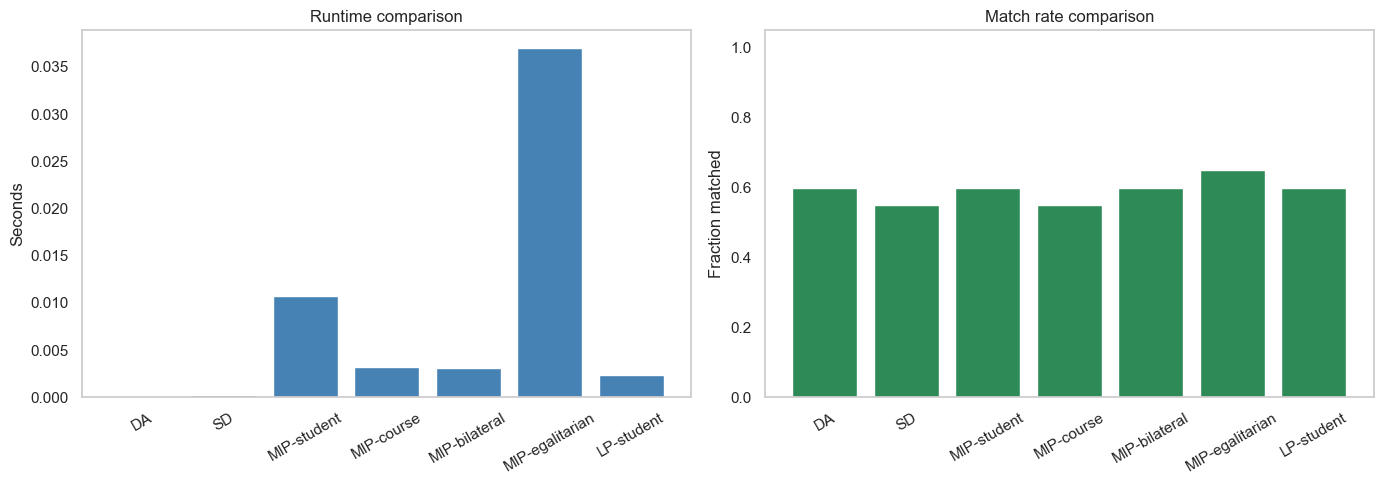

In [11]:
# plot runtime and match rate
summary_rows = []
for label, (a, rt) in results.items():
    summary_rows.append({
        "Algorithm": label,
        "Runtime (s)": rt,
        "Match rate": (a >= 0).sum() / m_default.n_students,
    })

df_summary = pd.DataFrame(summary_rows).set_index("Algorithm")
display(df_summary)

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

axes[0].bar(df_summary.index, df_summary["Runtime (s)"], color="steelblue")
axes[0].set_title("Runtime comparison")
axes[0].set_ylabel("Seconds")
axes[0].tick_params(axis="x", rotation=30)
axes[0].grid(False)

axes[1].bar(df_summary.index, df_summary["Match rate"], color="seagreen")
axes[1].set_title("Match rate comparison")
axes[1].set_ylabel("Fraction matched")
axes[1].set_ylim(0, 1.05)
axes[1].tick_params(axis="x", rotation=30)
axes[1].grid(False)

plt.tight_layout()
plt.show()


Results could be seed dependent, I also test across a series of random seeds

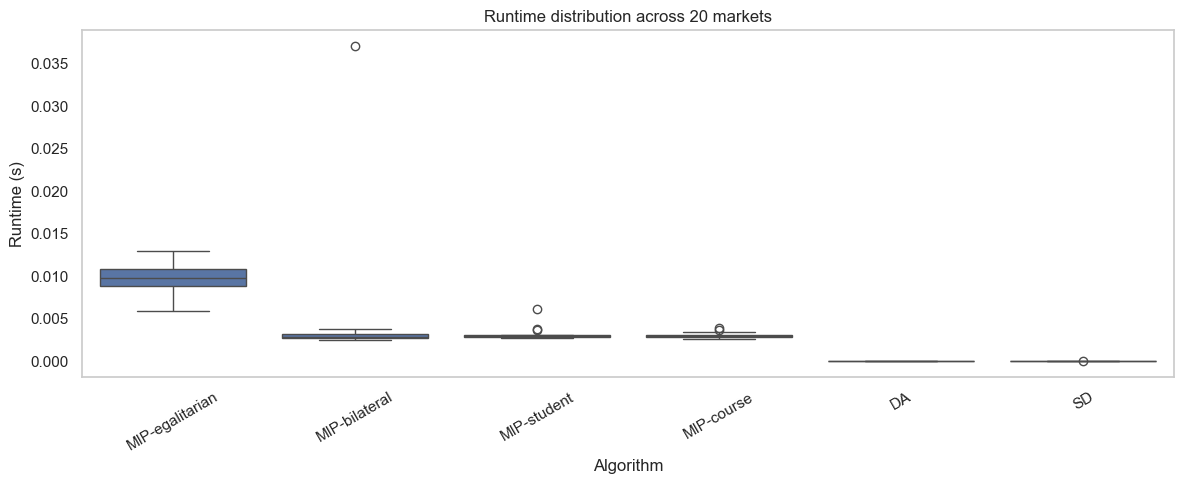

,mean,std,min,max
Algorithm,,,,
DA,0.0001,0.0000,0.0001,0.0001
MIP-bilateral,0.0047,0.0076,0.0026,0.0371
MIP-course,0.0030,0.0003,0.0027,0.0039
MIP-egalitarian,0.0098,0.0018,0.0059,0.0129
MIP-student,0.0032,0.0008,0.0027,0.0062
SD,0.0001,0.0000,0.0000,0.0001


In [12]:
# check runtime for different algorithms over multiple seeds
import warnings
SEEDS = range(20)
runtime_records = []

for seed in SEEDS:
    mkt = generate_market(n_students=20, n_courses=8, seed=seed)
    for obj in ("student", "course", "bilateral", "egalitarian"):
        t0 = time.perf_counter()
        solve_mip(mkt, objective=obj, solver=SOLVER)
        runtime_records.append({"Algorithm": f"MIP-{obj}", "Runtime (s)": time.perf_counter() - t0, "Seed": seed})
    for label, fn in [("DA", deferred_acceptance), ("SD", lambda mkt: serial_dictatorship(mkt, seed=seed))]:
        t0 = time.perf_counter()
        fn(mkt)
        runtime_records.append({"Algorithm": label, "Runtime (s)": time.perf_counter() - t0, "Seed": seed})

df_rt = pd.DataFrame(runtime_records)

fig, ax = plt.subplots(figsize=(12, 5))
order = df_rt.groupby("Algorithm")["Runtime (s)"].mean().sort_values(ascending=False).index
sns.boxplot(data=df_rt, x="Algorithm", y="Runtime (s)", order=order, ax=ax)
ax.set_title("Runtime distribution across 20 markets")
ax.tick_params(axis="x", rotation=30)
ax.grid(False)
plt.tight_layout()
plt.show()

display(df_rt.groupby("Algorithm")["Runtime (s)"].agg(["mean", "std", "min", "max"]).round(4))


### Sensitivity of underlying data (experiments with new simulated datasets)

*only testing with DA, SD MIP-student and MIP-egalitarian for simplicity. Look at welfare outcomes
Noise level / variance

Skill complexity (dimension of latent skill / trait vector)

Sparse preferences

Popular coures

In [13]:
ALGOS = ["DA", "SD", "MIP-student", "MIP-egalitarian"]

def run_experiment(param_name, param_values, n_seeds=10, **fixed_kwargs):
    records = []
    for val in param_values:
        kwargs = {**fixed_kwargs, param_name: val}
        for seed in range(n_seeds):
            mkt = generate_market(n_students=20, n_courses=8, seed=seed, **kwargs)
            assignments = {
                "DA":  deferred_acceptance(mkt),
                "SD":  serial_dictatorship(mkt, seed=seed),
            }
            for obj in ("student", "egalitarian"):
                assignments[f"MIP-{obj}"] = solve_mip(mkt, objective=obj, solver=SOLVER).assignment

            for algo, a in assignments.items():
                records.append({
                    "param":          val,
                    "Algorithm":      algo,
                    "Welfare":        sum(mkt.student_scores[i, a[i]] for i in range(mkt.n_students) if a[i] >= 0),
                    "Blocking pairs": count_blocking_pairs(a, mkt),
                    "Match rate":     (a >= 0).sum() / mkt.n_students,
                })
    return pd.DataFrame(records)

def plot_experiment(df, param_label, title):
    metrics = [("Welfare", "Total student welfare"),
               ("Blocking pairs", "Blocking pairs"),
               ("Match rate", "Match rate")]
    fig, axes = plt.subplots(1, 3, figsize=(16, 5))
    fig.suptitle(title)
    for ax, (metric, ylabel) in zip(axes, metrics):
        for algo in ALGOS:
            sub = df[df["Algorithm"] == algo].groupby("param")[metric].mean()
            ax.plot(sub.index, sub.values, marker="o", label=algo)
        ax.set_xlabel(param_label)
        ax.set_ylabel(ylabel)
        ax.set_title(ylabel)
        ax.legend(fontsize=8)
        ax.grid(False)
    plt.tight_layout()
    plt.show()


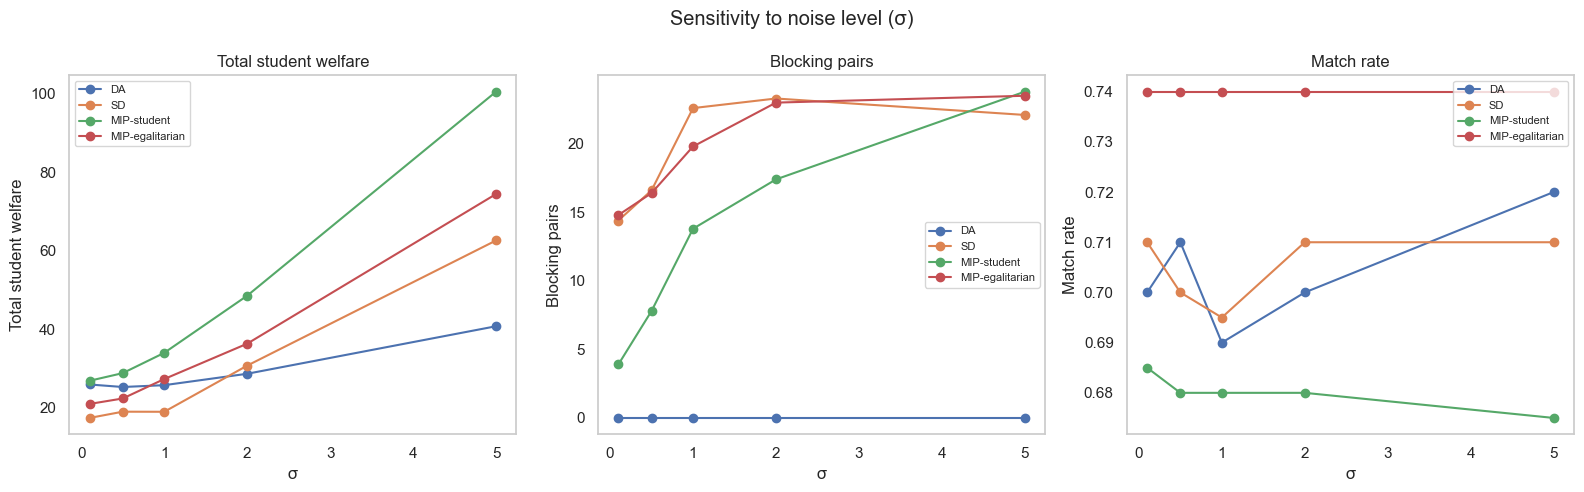

In [14]:
df_sigma = run_experiment("sigma", [0.1, 0.5, 1.0, 2.0, 5.0])
plot_experiment(df_sigma, "σ", "Sensitivity to noise level (σ)")

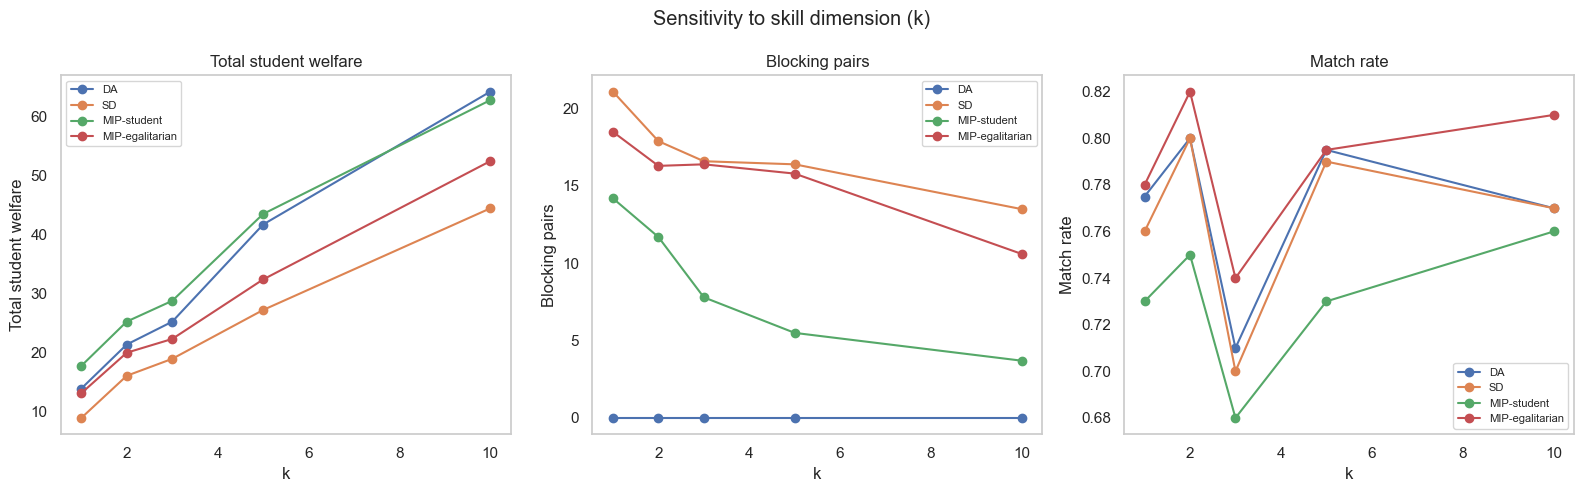

In [15]:
df_k = run_experiment("k", [1, 2, 3, 5, 10])
plot_experiment(df_k, "k", "Sensitivity to skill dimension (k)")


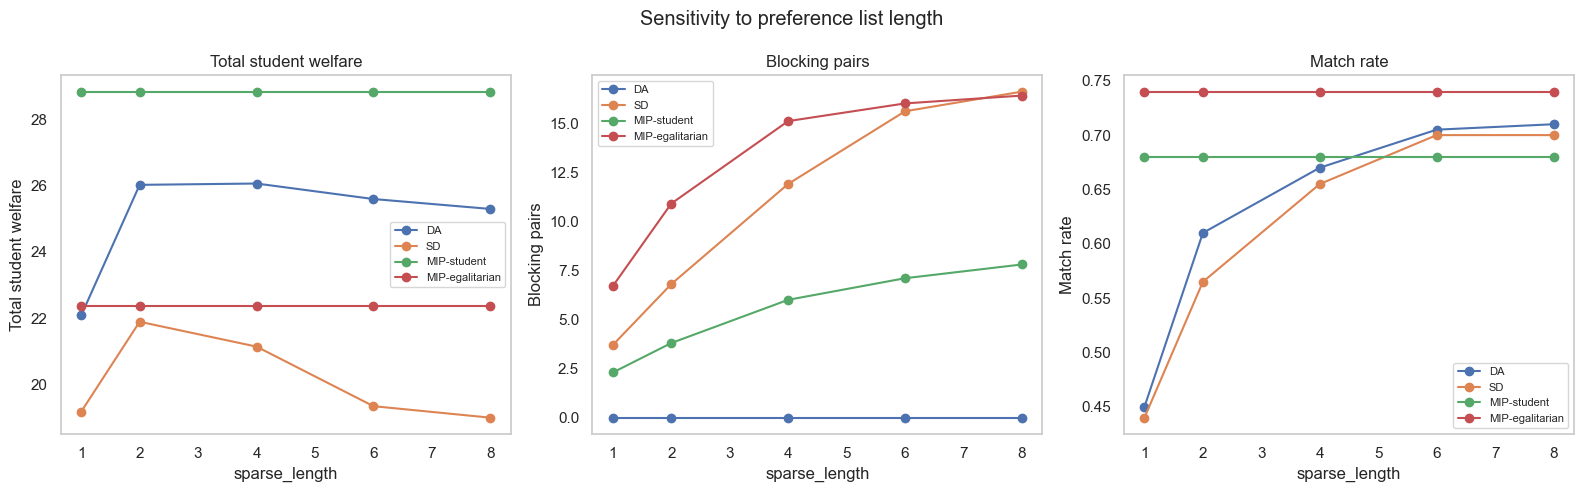

In [16]:
df_sparse = run_experiment("sparse_length", [1, 2, 4, 6, 8], sparse_prefs=True)
plot_experiment(df_sparse, "sparse_length", "Sensitivity to preference list length")

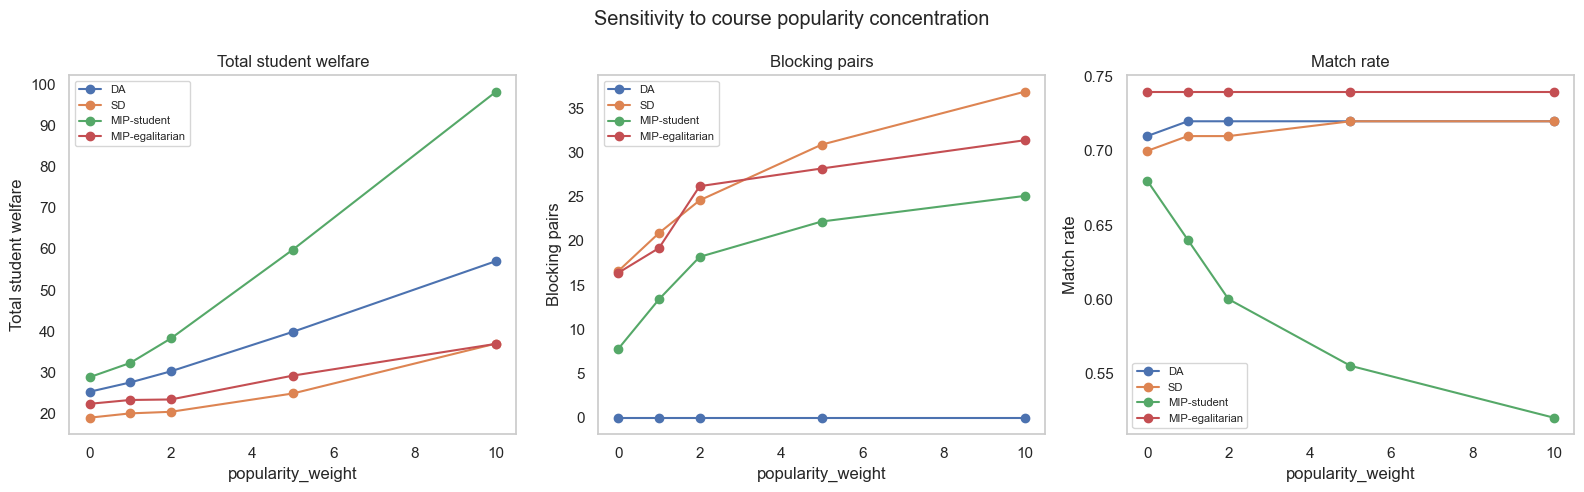

In [17]:
df_pop = run_experiment("popularity_weight", [0, 1, 2, 5, 10])
plot_experiment(df_pop, "popularity_weight", "Sensitivity to course popularity concentration")

### Using Winter 2026 TA assignment as an example? (the exact set?)
See attached TA POSTING doc, assume the same number of students as positions so everyone is matched.

In [18]:
# Real VSE TA market — Winter 2025-26 Term 2
REAL_COURSES = [
    "ECON101", "ECON102", "ECON221", "ECON241", "ECON301", "ECON302",
    "ECON306", "ECON307/408", "ECON309", "ECON316", "ECON317", "ECON323",
    "ECON325", "ECON326", "ECON328", "ECON345", "ECON351", "ECON355",
    "ECON356", "ECON398", "ECON425", "ECON442", "ECON456", "ECON473",
    "ECON490", "ECON490/553", "ECON492C", "ECON494", "ECON601", "ECON603",
    "ECON627",
]
REAL_CAPS = np.array([
    6, 20, 2, 1, 1, 2, 1, 1, 1, 1, 2, 1,
    1, 1, 1, 3, 1, 3, 3, 1, 1, 2, 2, 1,
    1, 1, 1, 1, 1, 1, 1,
])
REAL_PHD = np.array([
    False, False, False, False, False, False,
    False, False, False, False, False, False,
    False, False, False, False, False, False,
    False, False, False, False, False, False,
    False, False, False, False, True, True, True,  # 601, 603, 627
])

assert len(REAL_COURSES) == len(REAL_CAPS) == len(REAL_PHD)
n_slots = int(REAL_CAPS.sum())
print(f"Courses: {len(REAL_COURSES)}, Total slots: {n_slots}, Students: {n_slots}")

m_real = generate_market(
    n_students=n_slots,
    n_courses=len(REAL_COURSES),
    fixed_capacities=REAL_CAPS,
    fixed_course_codes=REAL_COURSES,
    fixed_phd_required=REAL_PHD,
    rejection_fraction=0.0,  # no rejection lists for real market
    seed=SEED,
)


Courses: 31, Total slots: 66, Students: 66


run all algorithms (using HiGHS for MIP since GUROBI license has limits on size)

In [21]:
# run all algorithms on real market
results_real = {
    "DA":  (deferred_acceptance(m_real), None),
    "SD":  (serial_dictatorship(m_real, seed=SEED), None),
    "MIP-student":     (solve_mip(m_real, objective="student",     solver="HIGHS").assignment, None),
    "MIP-egalitarian": (solve_mip(m_real, objective="egalitarian", solver="HIGHS").assignment, None),
}


# summary table
rows = []
for label, (a, _) in results_real.items():
    matched = (a >= 0).sum()
    ranks = [m_real.student_rankings[i, a[i]] for i in range(m_real.n_students) if a[i] >= 0]
    utils = [m_real.student_scores[i, a[i]] for i in range(m_real.n_students) if a[i] >= 0]
    rows.append({
        "Algorithm":    label,
        "Matched":      matched,
        "Mean rank":    round(np.mean(ranks), 2),
        "Median rank":  int(np.median(ranks)),
        "Total welfare": round(sum(utils), 2),
        "Min welfare":  round(min(utils), 2),
        "Blocking pairs": count_blocking_pairs(a, m_real),
    })

display(pd.DataFrame(rows).set_index("Algorithm"))



,Matched,Mean rank,Median rank,Total welfare,Min welfare,Blocking pairs
Algorithm,,,,,,
DA,66,4.80,3,130.62,-0.74,0
SD,66,5.67,3,105.97,-1.42,119
MIP-student,65,3.08,2,144.63,0.26,40
MIP-egalitarian,66,4.00,3,112.67,0.70,156
